In [51]:
# Notebook: inspect a pickle (.pk/.pkl) file interactively
#
# Usage:
# - Set PK_PATH to your file
# - (Optional) set SELECT_PATH like "obs/state/0" to focus on a sub-object

import os
import pickle
import pprint
from dataclasses import dataclass
from typing import Any, Iterable


def _optional_import_numpy():
    try:
        import numpy as np  # type: ignore

        return np
    except Exception:
        return None


def _optional_import_torch():
    try:
        import torch  # type: ignore

        return torch
    except Exception:
        return None


def _is_namedtuple(obj: Any) -> bool:
    t = type(obj)
    return isinstance(obj, tuple) and hasattr(obj, "_fields") and hasattr(t, "_asdict")


def _safe_repr(obj: Any, max_len: int = 200) -> str:
    try:
        s = repr(obj)
    except Exception as e:
        s = f"<repr failed: {type(e).__name__}: {e}>"
    if len(s) > max_len:
        return s[: max_len - 3] + "..."
    return s


def _shape_dtype_str(obj: Any) -> str | None:
    np = _optional_import_numpy()
    torch = _optional_import_torch()

    if np is not None and isinstance(obj, getattr(np, "ndarray")):
        return f"shape={tuple(obj.shape)} dtype={obj.dtype}"
    if torch is not None and isinstance(obj, getattr(torch, "Tensor")):
        try:
            device = str(obj.device)
        except Exception:
            device = "?"
        try:
            dtype = str(obj.dtype)
        except Exception:
            dtype = "?"
        try:
            shape = tuple(obj.shape)
        except Exception:
            shape = "?"
        return f"shape={shape} dtype={dtype} device={device}"
    return None


def _iter_preview(it: Iterable[Any], max_items: int) -> list[Any]:
    out: list[Any] = []
    for i, x in enumerate(it):
        if i >= max_items:
            break
        out.append(x)
    return out


@dataclass(frozen=True)
class InspectOptions:
    depth: int = 3
    max_items: int = 20
    max_str: int = 200
    show_values: bool = False
    sort_keys: bool = False


def inspect_obj(obj: Any, *, opts: InspectOptions = InspectOptions(), indent: int = 0, depth: int = 0) -> None:
    pad = " " * indent
    tname = type(obj).__name__
    extra = _shape_dtype_str(obj)
    if extra:
        print(f"{pad}{tname} ({extra})")
    else:
        print(f"{pad}{tname}")

    if depth >= opts.depth:
        if opts.show_values:
            print(f"{pad}  value={_safe_repr(obj, max_len=opts.max_str)}")
        return

    if isinstance(obj, dict):
        keys = list(obj.keys())
        if opts.sort_keys:
            try:
                keys = sorted(keys)
            except Exception:
                pass
        n = len(keys)
        print(f"{pad}  len={n}")
        for k in keys[: opts.max_items]:
            print(f"{pad}  [{_safe_repr(k, max_len=opts.max_str)}] -> ", end="")
            inspect_obj(obj[k], opts=opts, indent=indent + 4, depth=depth + 1)
        if n > opts.max_items:
            print(f"{pad}  ... ({n - opts.max_items} more keys)")
        return

    if _is_namedtuple(obj):
        try:
            d = obj._asdict()
        except Exception:
            d = None
        if isinstance(d, dict):
            print(f"{pad}  fields={list(d.keys())}")
            for k in list(d.keys())[: opts.max_items]:
                print(f"{pad}  .{k} -> ", end="")
                inspect_obj(d[k], opts=opts, indent=indent + 4, depth=depth + 1)
            return

    if isinstance(obj, (list, tuple)):
        n = len(obj)
        print(f"{pad}  len={n}")
        for i, x in enumerate(obj[: opts.max_items]):
            print(f"{pad}  [{i}] -> ", end="")
            inspect_obj(x, opts=opts, indent=indent + 4, depth=depth + 1)
        if n > opts.max_items:
            print(f"{pad}  ... ({n - opts.max_items} more items)")
        return

    if isinstance(obj, (set, frozenset)):
        n = len(obj)
        print(f"{pad}  len={n}")
        for i, x in enumerate(_iter_preview(obj, opts.max_items)):
            print(f"{pad}  [{i}] -> ", end="")
            inspect_obj(x, opts=opts, indent=indent + 4, depth=depth + 1)
        if n > opts.max_items:
            print(f"{pad}  ... ({n - opts.max_items} more items)")
        return

    if opts.show_values:
        print(f"{pad}  value={_safe_repr(obj, max_len=opts.max_str)}")


def get_by_path(obj: Any, path: str) -> Any:
    if not path:
        return obj
    cur = obj
    for raw in path.split("/"):
        if raw == "":
            continue
        if isinstance(cur, (list, tuple)):
            cur = cur[int(raw)]
            continue
        if isinstance(cur, dict):
            if raw in cur:
                cur = cur[raw]
                continue
            candidates: list[Any] = []
            try:
                candidates.append(int(raw))
            except Exception:
                pass
            try:
                candidates.append(float(raw))
            except Exception:
                pass
            if raw.lower() in ("true", "false"):
                candidates.append(raw.lower() == "true")
            for k in candidates:
                if k in cur:
                    cur = cur[k]
                    break
            else:
                raise KeyError(f"Path component {raw!r} not found in dict keys")
            continue
        if hasattr(cur, raw):
            cur = getattr(cur, raw)
            continue
        raise TypeError(f"Cannot descend into {type(cur).__name__} with component {raw!r}")
    return cur


def load_pickle(path: str) -> Any:
    with open(os.path.expanduser(path), "rb") as f:
        return pickle.load(f)


In [52]:

PK_PATH = "/home/khw/Projects/robomimic/datasets/puma_test/1776845895_4352164/ee_state_0.pk"  # <- set me
# PK_PATH = "/home/khw/Projects/pumafabrics/pumafabrics/puma_adapted/datasets/dingo_kinova/kinova_6feb_pick/ee_state_0.pk"  # <- set me

SELECT_PATH = ""  # optional, e.g. "obs/state/0"

assert PK_PATH, "Set PK_PATH to a .pk/.pkl file path"

In [53]:
# Load + select
obj = load_pickle(PK_PATH)
sel = get_by_path(obj, SELECT_PATH)

print(f"loaded: {PK_PATH}")
if SELECT_PATH:
    print(f"selected: {SELECT_PATH}\n")

# quick type check
print("type:", type(sel))

FileNotFoundError: [Errno 2] No such file or directory: '/home/khw/Projects/robomimic/datasets/puma_test/1776845895_4352164/ee_state_0.pk'

In [ ]:
# Structured summary (tune depth / max_items / show_values)
opts = InspectOptions(depth=3, max_items=20, max_str=200, show_values=False, sort_keys=False)
inspect_obj(sel, opts=opts)

dict
  len=4
  ['x_pos'] ->     list
      len=175
      [0] ->         ndarray (shape=(3,) dtype=float64)
      [1] ->         ndarray (shape=(3,) dtype=float64)
      [2] ->         ndarray (shape=(3,) dtype=float64)
      [3] ->         ndarray (shape=(3,) dtype=float64)
      [4] ->         ndarray (shape=(3,) dtype=float64)
      [5] ->         ndarray (shape=(3,) dtype=float64)
      [6] ->         ndarray (shape=(3,) dtype=float64)
      [7] ->         ndarray (shape=(3,) dtype=float64)
      [8] ->         ndarray (shape=(3,) dtype=float64)
      [9] ->         ndarray (shape=(3,) dtype=float64)
      [10] ->         ndarray (shape=(3,) dtype=float64)
      [11] ->         ndarray (shape=(3,) dtype=float64)
      [12] ->         ndarray (shape=(3,) dtype=float64)
      [13] ->         ndarray (shape=(3,) dtype=float64)
      [14] ->         ndarray (shape=(3,) dtype=float64)
      [15] ->         ndarray (shape=(3,) dtype=float64)
      [16] ->         ndarray (shape=(3,) dtype

In [ ]:
# Try to view the selected object as a pandas DataFrame
#
# This works best when `sel` is:
# - list[dict] (records)
# - dict[str, list/np.ndarray] with equal-length columns
# - 2D np.ndarray / torch.Tensor

try:
    import pandas as pd  # type: ignore
except Exception as e:
    raise RuntimeError("pandas is required for DataFrame viewing (pip install pandas)") from e

np = _optional_import_numpy()
torch = _optional_import_torch()


def to_dataframe(x: Any, *, max_rows: int | None = 200_000):
    # torch -> numpy
    if torch is not None and isinstance(x, getattr(torch, "Tensor")):
        x = x.detach().cpu().numpy()

    # numpy arrays
    if np is not None and isinstance(x, getattr(np, "ndarray")):
        if x.ndim == 1:
            return pd.DataFrame({"value": x})
        if x.ndim == 2:
            return pd.DataFrame(x)
        # flatten leading dims into rows
        rows = int(np.prod(x.shape[:-1]))
        last = int(x.shape[-1])
        return pd.DataFrame(x.reshape(rows, last))

    # list/tuple
    if isinstance(x, (list, tuple)):
        if len(x) == 0:
            return pd.DataFrame()
        # list of dicts
        if all(isinstance(r, dict) for r in x):
            return pd.DataFrame.from_records(list(x))
        # list of scalars
        return pd.DataFrame({"value": list(x)})

    # dict
    if isinstance(x, dict):
        # dict of columns
        try:
            return pd.DataFrame(x)
        except Exception:
            # fallback: one row
            return pd.DataFrame([x])

    # fallback scalar
    return pd.DataFrame({"value": [x]})


MAX_ROWS = 200_000  # cap for big pickles

df = to_dataframe(sel)
if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df = df.head(MAX_ROWS)

display(df.head(15))
print("rows:", len(df), "cols:", df.shape[1])

# Helpful summaries
try:
    display(df.describe(include="all").transpose())
except Exception:
    pass

# dtypes / null counts
display(pd.DataFrame({"dtype": df.dtypes.astype(str), "nulls": df.isna().sum()}))

,x_pos,x_rot,x_dot,delta_t
0,"[0.05115932249911706, 0.0001437887601975082, 1...","[[0.038156523244774504, 0.9881966449344073, 0....","[1.327561528260016e-10, 2.848438039545491e-09,...",0.411038
1,"[0.051159322509081534, 0.00014378896545662605,...","[[0.03815652360974181, 0.9881966449197626, 0.1...","[1.9670597450006798e-10, 4.0242691328068276e-0...",0.008996
2,"[0.051159322519721315, 0.00014378917448190013,...","[[0.03815652378367304, 0.9881966449116975, 0.1...","[1.6929117245481479e-10, 3.3124825579350395e-0...",0.046523
3,"[0.051159322527527695, 0.00014378932444760947,...","[[0.038156523812719584, 0.9881966449092615, 0....","[1.1385299367013832e-10, 2.194997716046422e-09...",0.050124
4,"[0.05115932253249187, 0.00014378941894942958, ...","[[0.03815652380590274, 0.9881966449086059, 0.1...","[6.984321742476963e-11, 1.3378779372499118e-09...",0.049922
5,"[0.05115932253459928, 0.00014378946013782787, ...","[[0.038156523827296895, 0.9881966449074725, 0....","[1.9254008672511045e-11, 3.990204410806931e-10...",0.050048
6,"[0.05115932253511209, 0.00014378947140888335, ...","[[0.03815652386556169, 0.9881966449060292, 0.1...","[3.5453870252089334e-12, 9.455118003867006e-11...",0.049999
7,"[0.051159322535174814, 0.00014378947373089106,...","[[0.03815652389594831, 0.988196644904946, 0.14...","[-3.14393036232345e-13, 1.1919408058131701e-11...",0.050218
8,"[0.05115932253513849, 0.0001437894737697002, 1...","[[0.038156523915784835, 0.9881966449042529, 0....","[-8.976246518336737e-13, -6.226997319676072e-1...",0.050216
9,"[0.051159322535095975, 0.00014378947339485334,...","[[0.03815652392776858, 0.9881966449038359, 0.1...","[-7.281436818078391e-13, -7.536109468335192e-1...",0.051574


rows: 175 cols: 4


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
x_pos,175,175,"[0.05115932249911706, 0.0001437887601975082, 1...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
x_rot,175,175,"[[0.038156523244774504, 0.9881966449344073, 0....",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
x_dot,175,175,"[1.327561528260016e-10, 2.848438039545491e-09,...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delta_t,175.0,NaN,NaN,NaN,0.051887,0.02749,0.008996,0.049978,0.05007,0.050206,0.411038


,dtype,nulls
x_pos,object,0
x_rot,object,0
x_dot,object,0
delta_t,float64,0


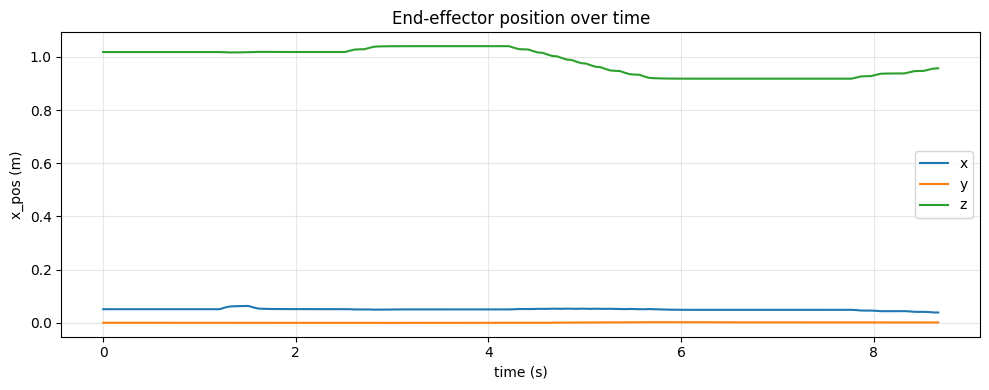

In [54]:
# Plot x_pos over time

np = _optional_import_numpy()
assert np is not None, "numpy is required for plotting"

try:
    import matplotlib.pyplot as plt  # type: ignore
except Exception as e:
    raise RuntimeError("matplotlib is required for plotting (pip install matplotlib)") from e

# Extract x_pos -> (T, 3)
x_pos = sel.get("x_pos", None) if isinstance(sel, dict) else None
assert x_pos is not None, "Expected `sel` to be a dict with key 'x_pos'"

x_pos_arr = np.asarray(x_pos, dtype=float)
if x_pos_arr.ndim == 1 and x_pos_arr.size == 3:
    x_pos_arr = x_pos_arr.reshape(1, 3)
assert x_pos_arr.ndim == 2 and x_pos_arr.shape[1] == 3, f"x_pos should be (T,3), got {x_pos_arr.shape}"

T = x_pos_arr.shape[0]

# Build time axis from delta_t if possible
delta_t = sel.get("delta_t", None) if isinstance(sel, dict) else None
if delta_t is None:
    t = np.arange(T)
    t_label = "timestep"
else:
    dt = np.asarray(delta_t, dtype=float).reshape(-1)
    if dt.shape[0] == T:
        t = np.cumsum(dt) - dt[0]  # start at 0
    elif dt.shape[0] == T - 1:
        t = np.concatenate([[0.0], np.cumsum(dt)])
    else:
        t = np.arange(T)
    t_label = "time (s)" if t.dtype.kind in "fc" else "timestep"

plt.figure(figsize=(10, 4))
plt.plot(t, x_pos_arr[:, 0], label="x")
plt.plot(t, x_pos_arr[:, 1], label="y")
plt.plot(t, x_pos_arr[:, 2], label="z")
plt.xlabel(t_label)
plt.ylabel("x_pos (m)")
plt.title("End-effector position over time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()